In [9]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns


Shapes: (2, 3, 4) (2, 3, 4) (2, 3, 4)


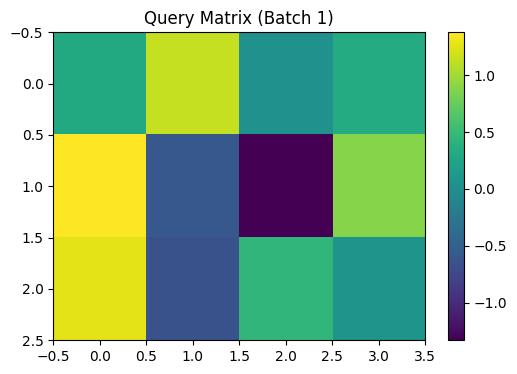

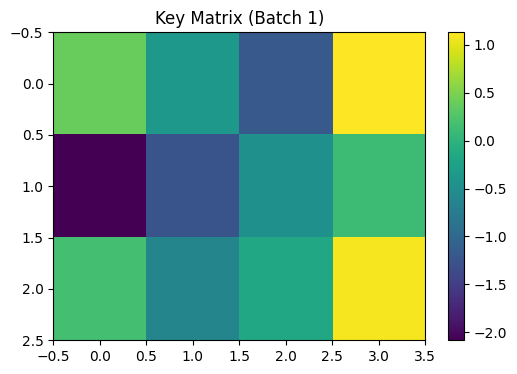

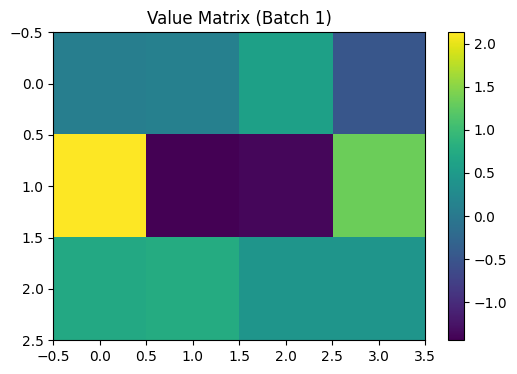

In [10]:
def plot_matrix(matrix, title):
    plt.figure(figsize=(6,4))
    plt.imshow(matrix, cmap='viridis', aspect='auto')
    plt.title(title)
    plt.colorbar()

input_sequence = np.array([
    [[1, 0, 1, 0],
     [0, 2, 1, 0],
     [1, 1, 0, 1]],

    [[0, 1, 0, 1],
     [2, 0, 1, 1],
     [1, 2, 0, 0]]
])


def compute_qkv(x):
    """Compute Q, K, V matrices from a 3D input sequence (batch, seq_len, dim)."""
    dense_q = tf.keras.layers.Dense(d_model)
    dense_k = tf.keras.layers.Dense(d_model)
    dense_v = tf.keras.layers.Dense(d_model)
    Q = dense_q(x)
    K = dense_k(x)
    V = dense_v(x)
    return Q, K, V

Q, K, V = compute_qkv(input_sequence)

print("Shapes:", Q.shape, K.shape, V.shape)
plot_matrix(Q[0], "Query Matrix (Batch 1)")
plot_matrix(K[0], "Key Matrix (Batch 1)")
plot_matrix(V[0], "Value Matrix (Batch 1)")


Output shape: (2, 3, 4)


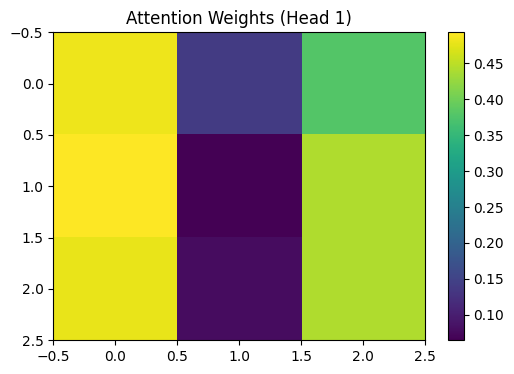

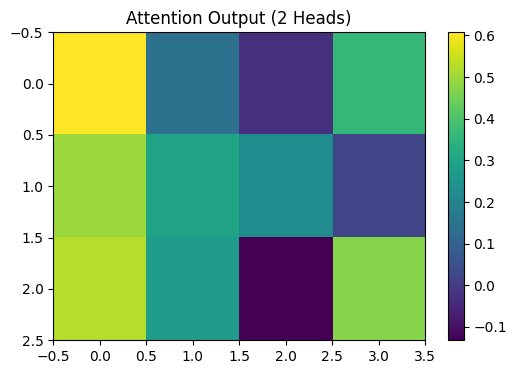

In [11]:
def scaled_dot_product_attention(Q, K, V):
    """Compute scaled dot-product attention for one head."""
    scores = tf.matmul(Q, K, transpose_b=True)
    dk = tf.cast(tf.shape(K)[-1], tf.float32)
    scaled_scores = scores / tf.math.sqrt(dk)
    weights = tf.nn.softmax(scaled_scores, axis=-1)
    output = tf.matmul(weights, V)
    return output, weights

def multi_head_attention(Q, K, V, num_heads=2):
    """Simple multi-head attention implementation."""
    d_model = Q.shape[-1]
    assert d_model % num_heads == 0, "Embedding dim must be divisible by number of heads"
    depth = d_model // num_heads

    Q_split = tf.concat(tf.split(Q, num_heads, axis=-1), axis=0)
    K_split = tf.concat(tf.split(K, num_heads, axis=-1), axis=0)
    V_split = tf.concat(tf.split(V, num_heads, axis=-1), axis=0)

    output, weights = scaled_dot_product_attention(Q_split, K_split, V_split)

    output = tf.concat(tf.split(output, num_heads, axis=0), axis=-1)
    return output, weights

output_multi, weights_multi = multi_head_attention(Q, K, V, num_heads=2)

plot_matrix(weights_multi[0], "Attention Weights (Head 1)")
plot_matrix(output_multi[0], "Attention Output (2 Heads)")

print("Output shape:", output_multi.shape)


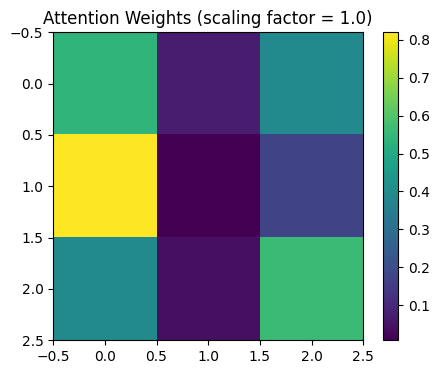

--- Scale = 1 ---
Attention Weights (first token): [0.53964794 0.06801743 0.3923347 ]
Sum of weights (should be ~1): 1.0



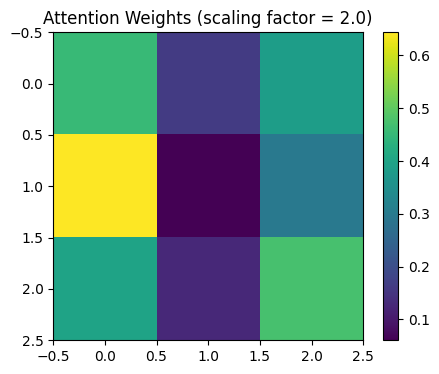

--- Scale = 2 ---
Attention Weights (first token): [0.452965   0.16081238 0.38622266]
Sum of weights (should be ~1): 1.0



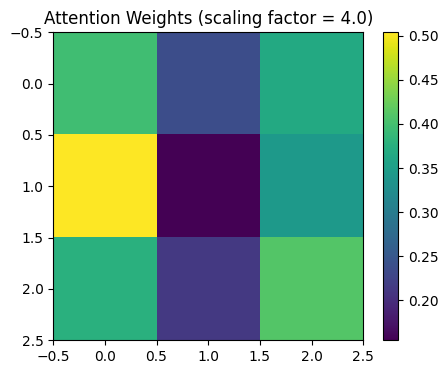

--- Scale = 4 ---
Attention Weights (first token): [0.3969467  0.23651552 0.36653778]
Sum of weights (should be ~1): 1.0



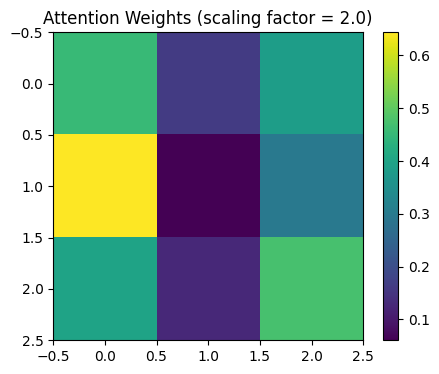

--- Scale = 2.0 ---
Attention Weights (first token): [0.452965   0.16081238 0.38622266]
Sum of weights (should be ~1): 1.0



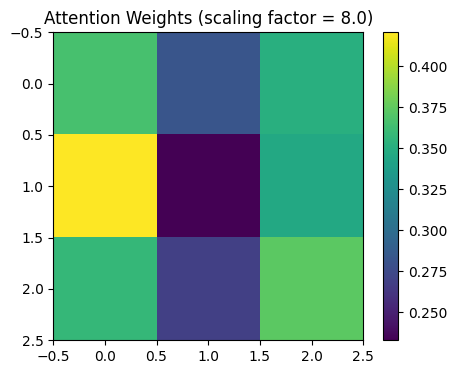

--- Scale = 8 ---
Attention Weights (first token): [0.36591995 0.28245535 0.35162467]
Sum of weights (should be ~1): 0.99999994



In [12]:
scaling_factors = [1, 2, 4, np.sqrt(d_model), 8]

for scale in scaling_factors:
    # Compute attention scores with a custom scale factor
    scores = tf.matmul(Q, K, transpose_b=True) / scale
    weights = tf.nn.softmax(scores, axis=-1)
    output = tf.matmul(weights, V)

   
    plt.figure(figsize=(5,4))
    plt.imshow(weights[0], cmap='viridis', aspect='auto')
    plt.title(f'Attention Weights (scaling factor = {round(float(scale), 2)})')
    plt.colorbar()
    plt.show()

    print(f"--- Scale = {scale} ---")
    print("Attention Weights (first token):", weights[0, 0].numpy())
    print("Sum of weights (should be ~1):", np.sum(weights[0, 0].numpy()))
    print()


Exo 2 

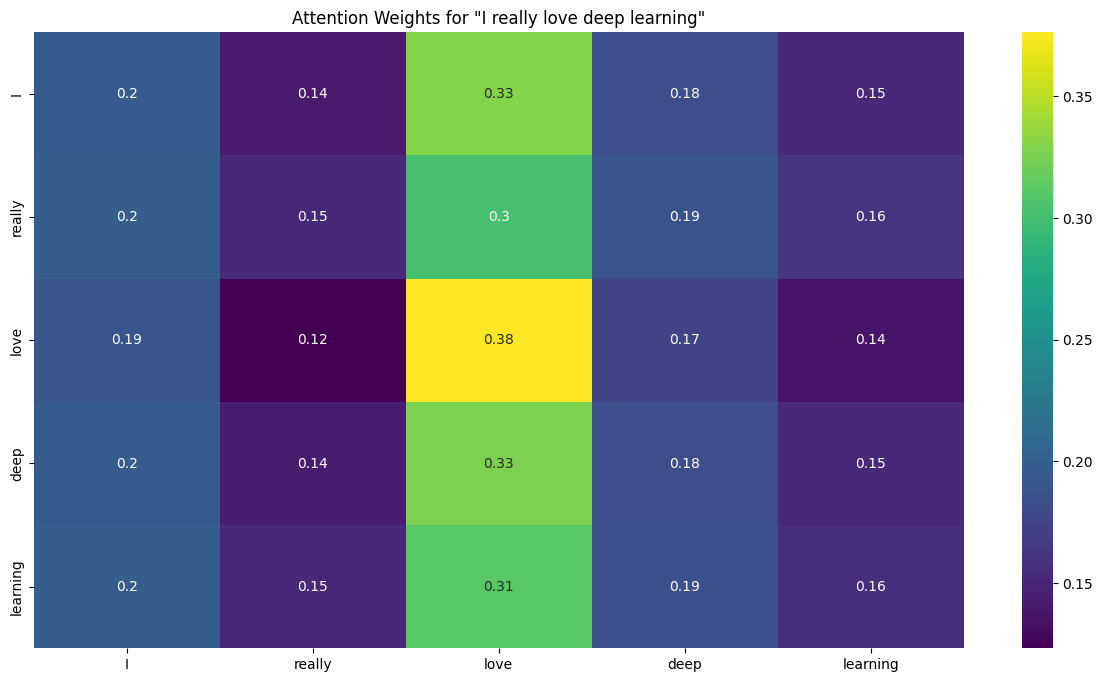

Sentence: ['I', 'really', 'love', 'deep', 'learning']

Query (Q):
 [[1.08605068 0.91148242 1.62732485]
 [0.89331694 0.67766829 1.37241611]
 [1.5021852  1.22941113 1.98921611]
 [1.07216608 0.94063706 1.50687558]
 [0.82652167 0.84954695 1.43421674]]

Key (K):
 [[0.8999922  1.19109738 0.65018674]
 [0.63553418 1.06983873 0.54840913]
 [1.149128   1.49149167 0.87208898]
 [0.93319148 1.06802094 0.62452144]
 [0.96036051 0.90152322 0.49764387]]

Value (V):
 [[1.16070488 0.66823493 1.27735215]
 [1.00943111 0.50380933 1.01863896]
 [1.4516347  0.90483163 1.53302987]
 [1.06318398 0.68578878 1.21516006]
 [0.93788338 0.6072435  1.25541956]]

Attention Weights:
 [[0.19546665 0.14119342 0.32969629 0.18260493 0.15103871]
 [0.19768448 0.15174304 0.30142556 0.18778633 0.16136059]
 [0.1898655  0.12322309 0.37632658 0.17386402 0.13672081]
 [0.19592624 0.14254189 0.32640804 0.18293309 0.15219074]
 [0.19782335 0.1510219  0.31023949 0.18522987 0.15568539]]

Output:
 [[1.18380203 0.71701753 1.31045029]
 [1.1711

In [13]:
def softmax(x):
    return np.exp(x) / np.sum(np.exp(x), axis=-1, keepdims=True)

sentence = ["I", "really", "love", "deep", "learning"]
np.random.seed(0)

embeddings = {word: np.random.rand(3) for word in sentence}
inputs = np.array([embeddings[word] for word in sentence])

Wq = np.random.rand(3, 3)
Wk = np.random.rand(3, 3)
Wv = np.random.rand(3, 3)

# --- Compute Q, K, V ---
Q = np.dot(inputs, Wq)
K = np.dot(inputs, Wk)
V = np.dot(inputs, Wv)

scores = np.dot(Q, K.T) / np.sqrt(K.shape[1])
attention_weights = softmax(scores)
output = np.dot(attention_weights, V)

plt.figure(figsize=(15, 8))
sns.heatmap(attention_weights, annot=True, cmap='viridis',
            xticklabels=sentence, yticklabels=sentence)
plt.title('Attention Weights for "I really love deep learning"')
plt.show()

print("Sentence:", sentence)
print("\nQuery (Q):\n", Q)
print("\nKey (K):\n", K)
print("\nValue (V):\n", V)
print("\nAttention Weights:\n", attention_weights)
print("\nOutput:\n", output)


/var/folders/8x/b_5n9ykn4kd4b9r56vp1d85h0000gn/T/ipykernel_55180/4280006622.py:2: RuntimeWarning: invalid value encountered in divide
  return np.exp(x) / np.sum(np.exp(x), axis=-1, keepdims=True)


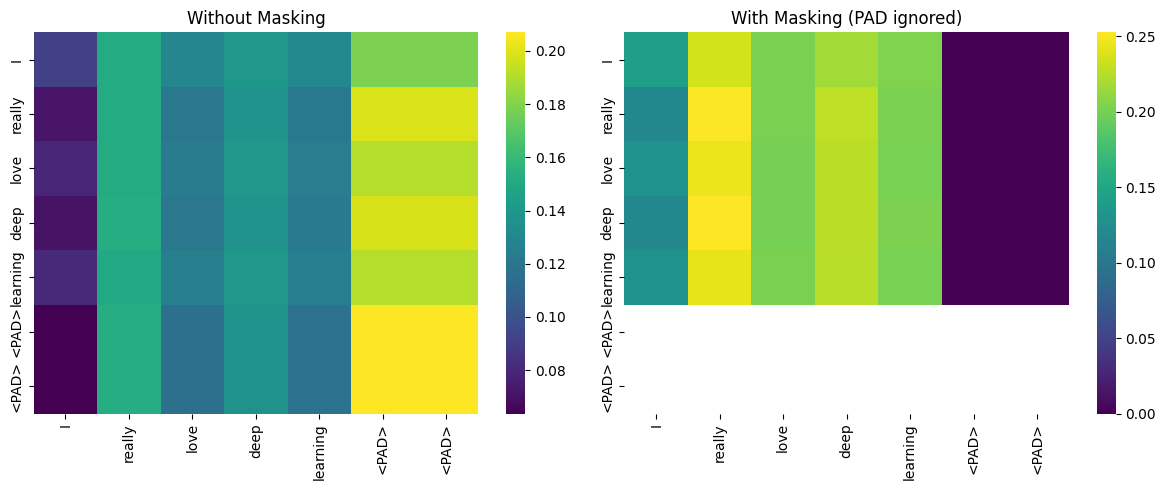

In [17]:
sentence_masked = ["I", "really", "love", "deep", "learning", "<PAD>", "<PAD>"]
vocab_size = len(sentence_masked)

embeddings_masked = {word: np.random.rand(3) for word in sentence_masked}
inputs_masked = np.array([embeddings_masked[word] for word in sentence_masked])

Q = np.dot(inputs_masked, Wq)
K = np.dot(inputs_masked, Wk)
V = np.dot(inputs_masked, Wv)

scores = np.dot(Q, K.T) / np.sqrt(K.shape[1])

mask = np.array([[1]*5 + [0]*2])  
mask = mask.T @ mask  # (7x7)

masked_scores = np.where(mask==1, scores, -1e9)
attention_weights_masked = softmax(masked_scores)
attention_weights_nomask = softmax(scores)

# --- Visualization comparison ---
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(attention_weights_nomask, cmap='viridis', xticklabels=sentence_masked, yticklabels=sentence_masked)
plt.title("Without Masking")
plt.subplot(1,2,2)
sns.heatmap(attention_weights_masked, cmap='viridis', xticklabels=sentence_masked, yticklabels=sentence_masked)
plt.title("With Masking (PAD ignored)")
plt.tight_layout()
plt.show()


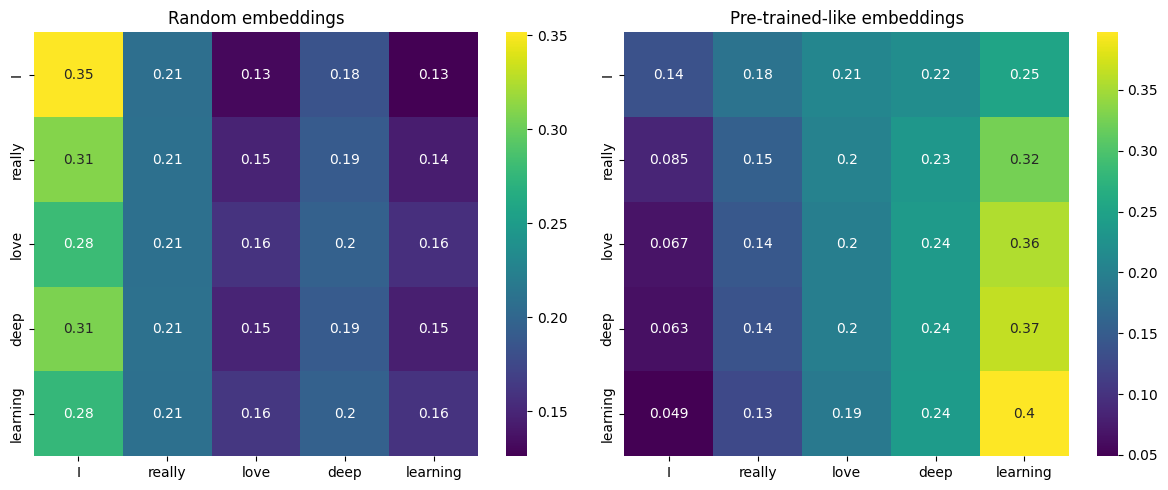

In [18]:
emb_random = {word: np.random.rand(3) for word in sentence}

emb_pretrained = {
    "I": [0.9, 0.1, 0.2],
    "really": [0.4, 0.8, 0.3],
    "love": [0.1, 0.7, 0.9],
    "deep": [0.5, 0.9, 0.6],
    "learning": [0.6, 1.0, 0.8]
}

def attention_from_embeddings(emb_dict):
    inp = np.array([emb_dict[w] for w in sentence])
    Q = np.dot(inp, Wq)
    K = np.dot(inp, Wk)
    V = np.dot(inp, Wv)
    scores = np.dot(Q, K.T) / np.sqrt(K.shape[1])
    weights = softmax(scores)
    return weights

weights_random = attention_from_embeddings(emb_random)
weights_pretrained = attention_from_embeddings(emb_pretrained)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(weights_random, annot=True, cmap='viridis', xticklabels=sentence, yticklabels=sentence)
plt.title("Random embeddings")
plt.subplot(1,2,2)
sns.heatmap(weights_pretrained, annot=True, cmap='viridis', xticklabels=sentence, yticklabels=sentence)
plt.title("Pre-trained-like embeddings")
plt.tight_layout()
plt.show()


EXO 3 

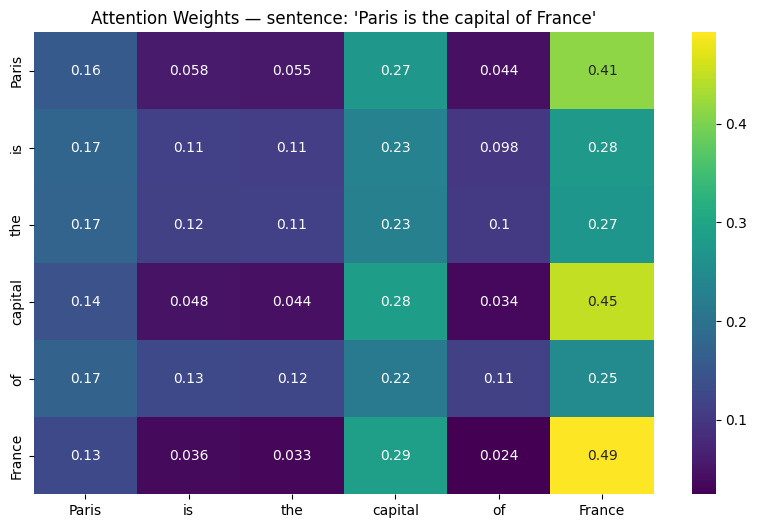

Output shape: (6, 4)


In [20]:
sentence = ["Paris", "is", "the", "capital", "of", "France"]

embeddings = {
    "Paris":   [0.9, 0.1, 0.8, 0.3],
    "is":      [0.3, 0.7, 0.2, 0.1],
    "the":     [0.2, 0.5, 0.3, 0.2],
    "capital": [0.8, 0.9, 0.7, 0.5],
    "of":      [0.1, 0.4, 0.2, 0.3],
    "France":  [0.9, 0.8, 0.9, 0.7]
}

inputs = np.array([embeddings[w] for w in sentence])
d_model = inputs.shape[1]

np.random.seed(42)
Wq = np.random.rand(d_model, d_model)
Wk = np.random.rand(d_model, d_model)
Wv = np.random.rand(d_model, d_model)

Q = np.dot(inputs, Wq)
K = np.dot(inputs, Wk)
V = np.dot(inputs, Wv)

scores = np.dot(Q, K.T) / np.sqrt(K.shape[1])
weights = np.exp(scores) / np.sum(np.exp(scores), axis=-1, keepdims=True)
output = np.dot(weights, V)

plt.figure(figsize=(10,6))
sns.heatmap(weights, annot=True, cmap="viridis",
            xticklabels=sentence, yticklabels=sentence)
plt.title("Attention Weights — sentence: 'Paris is the capital of France'")
plt.show()

print("Output shape:", output.shape)


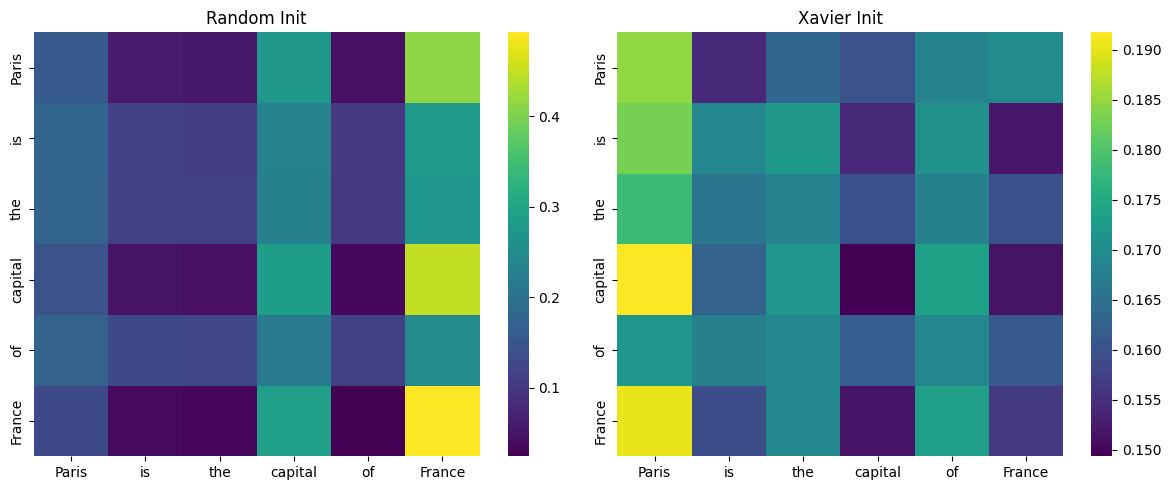

In [21]:
def xavier_init(shape):
    limit = np.sqrt(6 / sum(shape))
    return np.random.uniform(-limit, limit, shape)

Wq_xav = xavier_init((d_model, d_model))
Wk_xav = xavier_init((d_model, d_model))
Wv_xav = xavier_init((d_model, d_model))

Qx = np.dot(inputs, Wq_xav)
Kx = np.dot(inputs, Wk_xav)
Vx = np.dot(inputs, Wv_xav)

scores_x = np.dot(Qx, Kx.T) / np.sqrt(Kx.shape[1])
weights_x = np.exp(scores_x) / np.sum(np.exp(scores_x), axis=-1, keepdims=True)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(weights, cmap="viridis", xticklabels=sentence, yticklabels=sentence)
plt.title("Random Init")
plt.subplot(1,2,2)
sns.heatmap(weights_x, cmap="viridis", xticklabels=sentence, yticklabels=sentence)
plt.title("Xavier Init")
plt.tight_layout()
plt.show()


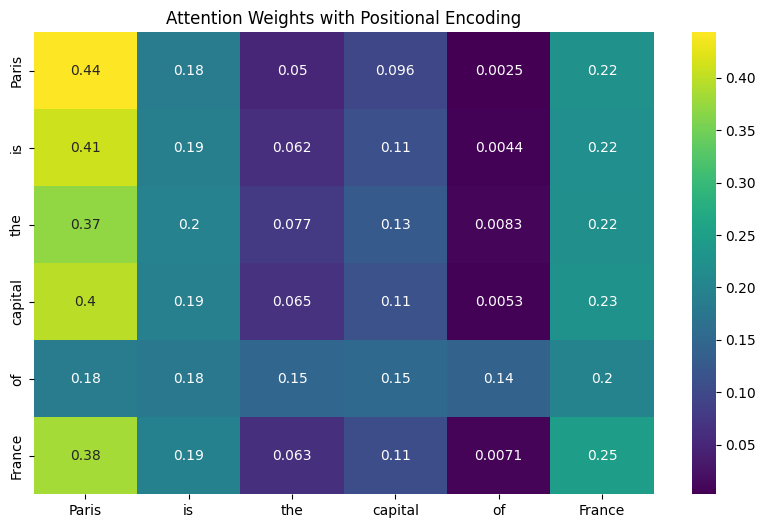

In [22]:
def positional_encoding(position, d_model):
    """Compute standard sinusoidal positional encoding."""
    PE = np.zeros((position, d_model))
    for pos in range(position):
        for i in range(0, d_model, 2):
            PE[pos, i] = np.sin(pos / (10000 ** ((2 * i)/d_model)))
            if i + 1 < d_model:
                PE[pos, i + 1] = np.cos(pos / (10000 ** ((2 * i)/d_model)))
    return PE

pos_enc = positional_encoding(len(sentence), d_model)
inputs_pos = inputs + pos_enc

Qp = np.dot(inputs_pos, Wq)
Kp = np.dot(inputs_pos, Wk)
Vp = np.dot(inputs_pos, Wv)

scores_p = np.dot(Qp, Kp.T) / np.sqrt(Kp.shape[1])
weights_p = np.exp(scores_p) / np.sum(np.exp(scores_p), axis=-1, keepdims=True)

plt.figure(figsize=(10,6))
sns.heatmap(weights_p, annot=True, cmap="viridis",
            xticklabels=sentence, yticklabels=sentence)
plt.title("Attention Weights with Positional Encoding")
plt.show()


Exo 4 

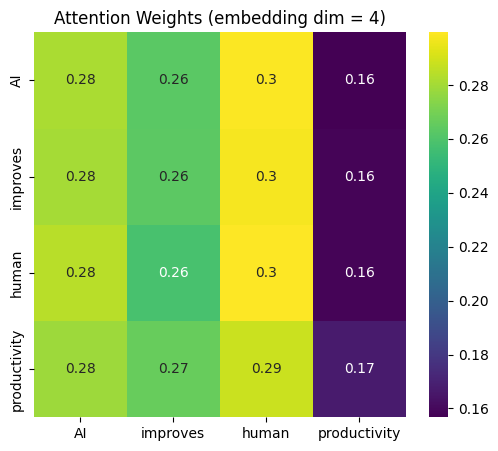

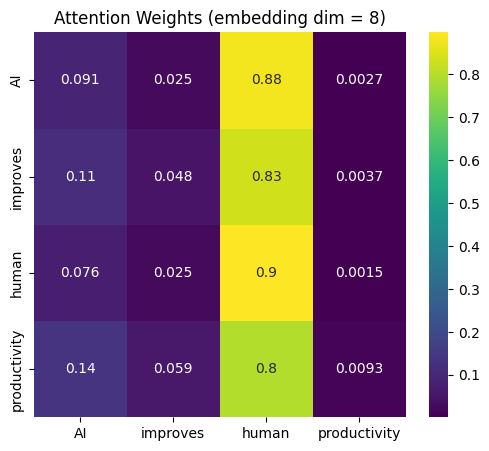

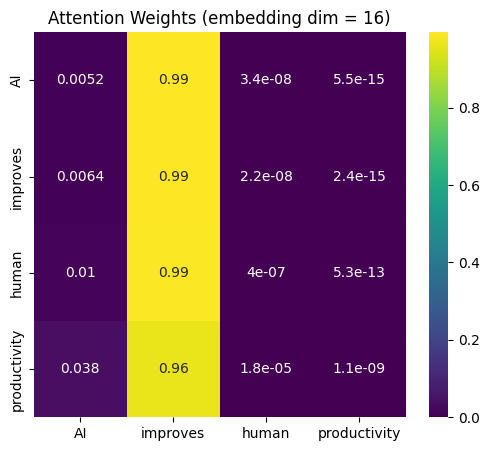

In [23]:
def softmax(x):
    return np.exp(x) / np.sum(np.exp(x), axis=-1, keepdims=True)

sentence = ["AI", "improves", "human", "productivity"]

for d_model in [4, 8, 16]:
    np.random.seed(0)

    inputs = np.random.rand(len(sentence), d_model)

    Wq = np.random.rand(d_model, d_model)
    Wk = np.random.rand(d_model, d_model)
    Wv = np.random.rand(d_model, d_model)

    Q = np.dot(inputs, Wq)
    K = np.dot(inputs, Wk)
    V = np.dot(inputs, Wv)

    scores = np.dot(Q, K.T) / np.sqrt(d_model)
    weights = softmax(scores)
    output = np.dot(weights, V)

    plt.figure(figsize=(6, 5))
    sns.heatmap(weights, annot=True, cmap="viridis",
                xticklabels=sentence, yticklabels=sentence)
    plt.title(f"Attention Weights (embedding dim = {d_model})")
    plt.show()


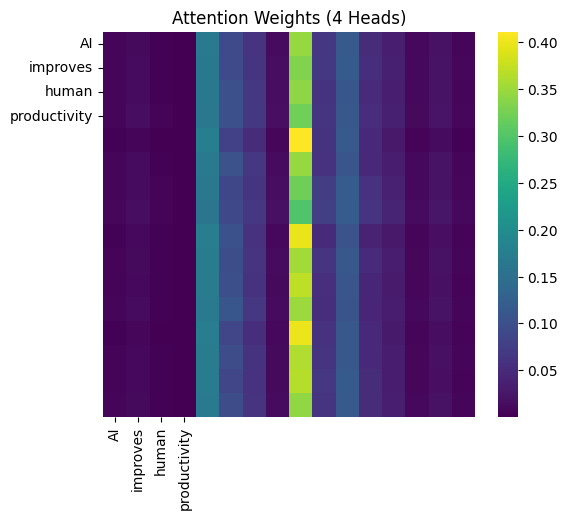

In [27]:
def scaled_dot_product_attention(Q, K, V):
    scores = np.dot(Q, K.T) / np.sqrt(K.shape[-1])
    weights = softmax(scores)
    output = np.dot(weights, V)
    return output, weights

def multi_head_attention(Q, K, V, num_heads):
    d_model = Q.shape[-1]
    depth = d_model // num_heads
    # Split each into heads
    Q_heads = np.concatenate(np.split(Q, num_heads, axis=-1), axis=0)
    K_heads = np.concatenate(np.split(K, num_heads, axis=-1), axis=0)
    V_heads = np.concatenate(np.split(V, num_heads, axis=-1), axis=0)

    outputs, weights = scaled_dot_product_attention(Q_heads, K_heads, V_heads)
    # Combine heads
    output = np.concatenate(np.split(outputs, num_heads, axis=0), axis=-1)
    return output, weights

d_model = 8
inputs = np.random.rand(len(sentence), d_model)
Wq = np.random.rand(d_model, d_model)
Wk = np.random.rand(d_model, d_model)
Wv = np.random.rand(d_model, d_model)
Q = np.dot(inputs, Wq)
K = np.dot(inputs, Wk)
V = np.dot(inputs, Wv)

output_4h, weights_4h = multi_head_attention(Q, K, V, num_heads=4)

plt.figure(figsize=(6,5))
sns.heatmap(weights_4h, cmap="viridis", xticklabels=sentence, yticklabels=sentence)
plt.title("Attention Weights (4 Heads)")
plt.show()


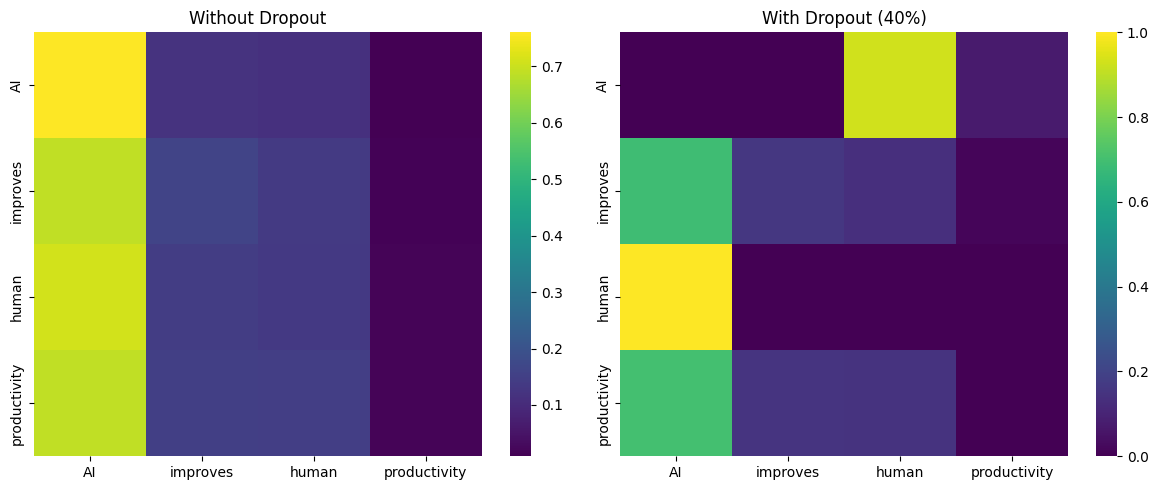

In [28]:
def attention_with_dropout(Q, K, V, dropout_rate=0.3):
    scores = np.dot(Q, K.T) / np.sqrt(K.shape[-1])
    weights = softmax(scores)

    dropout_mask = np.random.rand(*weights.shape) > dropout_rate
    weights_dropped = weights * dropout_mask
    weights_dropped /= np.sum(weights_dropped, axis=-1, keepdims=True)

    output = np.dot(weights_dropped, V)
    return weights, weights_dropped, output

weights_no, weights_drop, output_drop = attention_with_dropout(Q, K, V, dropout_rate=0.4)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(weights_no, cmap='viridis', xticklabels=sentence, yticklabels=sentence)
plt.title("Without Dropout")
plt.subplot(1,2,2)
sns.heatmap(weights_drop, cmap='viridis', xticklabels=sentence, yticklabels=sentence)
plt.title("With Dropout (40%)")
plt.tight_layout()
plt.show()


Exo 5 

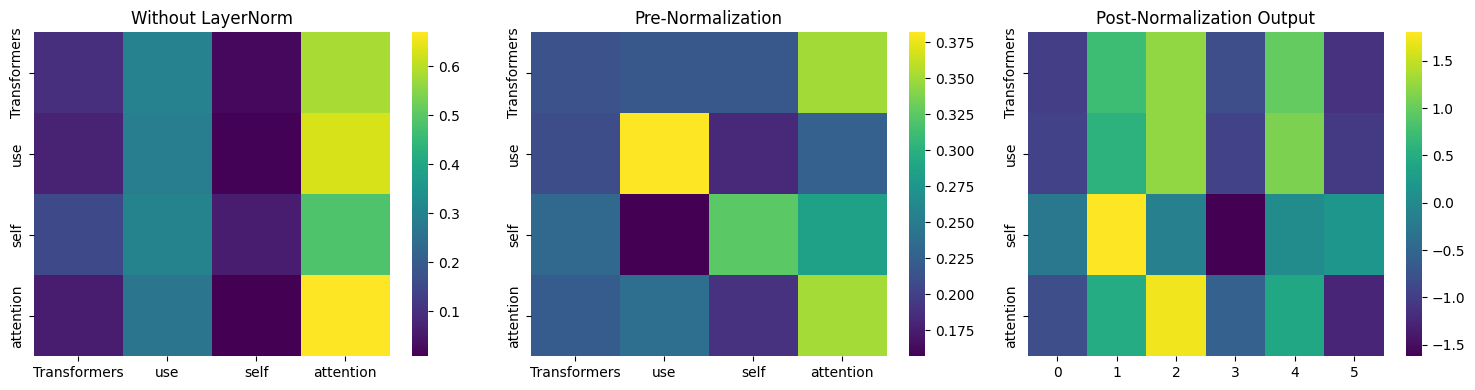

In [29]:
def softmax(x):
    return np.exp(x) / np.sum(np.exp(x), axis=-1, keepdims=True)

def layer_norm(x, eps=1e-6):
    """Layer normalization along last dimension."""
    mean = np.mean(x, axis=-1, keepdims=True)
    std = np.std(x, axis=-1, keepdims=True)
    return (x - mean) / (std + eps)

sentence = ["Transformers", "use", "self", "attention"]

np.random.seed(0)
inputs = np.random.rand(len(sentence), 6)
d_model = inputs.shape[-1]

Wq = np.random.rand(d_model, d_model)
Wk = np.random.rand(d_model, d_model)
Wv = np.random.rand(d_model, d_model)

Q = np.dot(inputs, Wq)
K = np.dot(inputs, Wk)
V = np.dot(inputs, Wv)
scores = np.dot(Q, K.T) / np.sqrt(d_model)
weights_no_norm = softmax(scores)
output_no_norm = np.dot(weights_no_norm, V)

inputs_norm = layer_norm(inputs)
Qn = np.dot(inputs_norm, Wq)
Kn = np.dot(inputs_norm, Wk)
Vn = np.dot(inputs_norm, Wv)
scores_pre = np.dot(Qn, Kn.T) / np.sqrt(d_model)
weights_pre = softmax(scores_pre)
output_pre = np.dot(weights_pre, Vn)

output_post = layer_norm(output_no_norm + inputs)

plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
sns.heatmap(weights_no_norm, cmap='viridis', xticklabels=sentence, yticklabels=sentence)
plt.title("Without LayerNorm")
plt.subplot(1,3,2)
sns.heatmap(weights_pre, cmap='viridis', xticklabels=sentence, yticklabels=sentence)
plt.title("Pre-Normalization")
plt.subplot(1,3,3)
sns.heatmap(output_post, cmap='viridis', xticklabels=range(d_model), yticklabels=sentence)
plt.title("Post-Normalization Output")
plt.tight_layout()
plt.show()


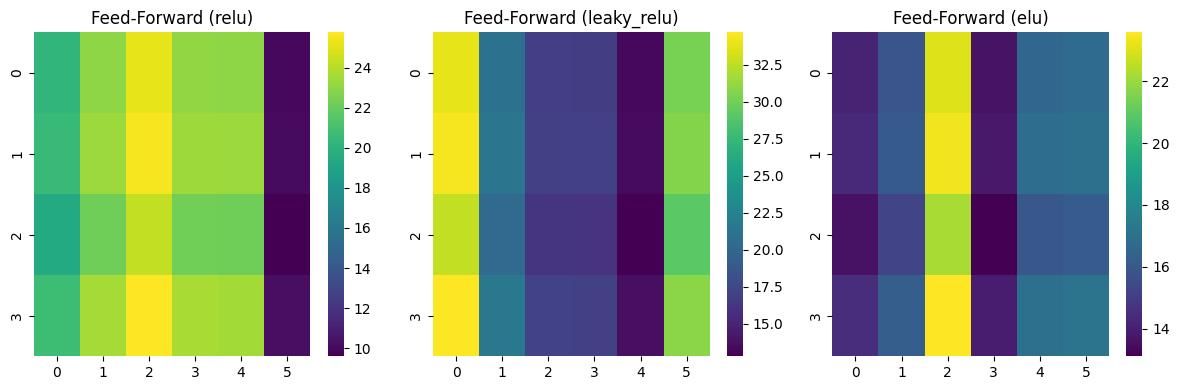

In [30]:
def feed_forward(x, activation="relu"):
    W1 = np.random.rand(d_model, d_model)
    W2 = np.random.rand(d_model, d_model)
    z = np.dot(x, W1)
    if activation == "relu":
        a = np.maximum(0, z)
    elif activation == "leaky_relu":
        a = np.where(z > 0, z, 0.1 * z)
    elif activation == "elu":
        a = np.where(z > 0, z, np.exp(z) - 1)
    return np.dot(a, W2)

activations = ["relu", "leaky_relu", "elu"]
plt.figure(figsize=(12,4))
for i, act in enumerate(activations):
    out = feed_forward(output_no_norm, act)
    plt.subplot(1,3,i+1)
    sns.heatmap(out, cmap='viridis')
    plt.title(f"Feed-Forward ({act})")
plt.tight_layout()
plt.show()


/var/folders/8x/b_5n9ykn4kd4b9r56vp1d85h0000gn/T/ipykernel_55180/538120230.py:2: RuntimeWarning: invalid value encountered in divide
  return np.exp(x) / np.sum(np.exp(x), axis=-1, keepdims=True)


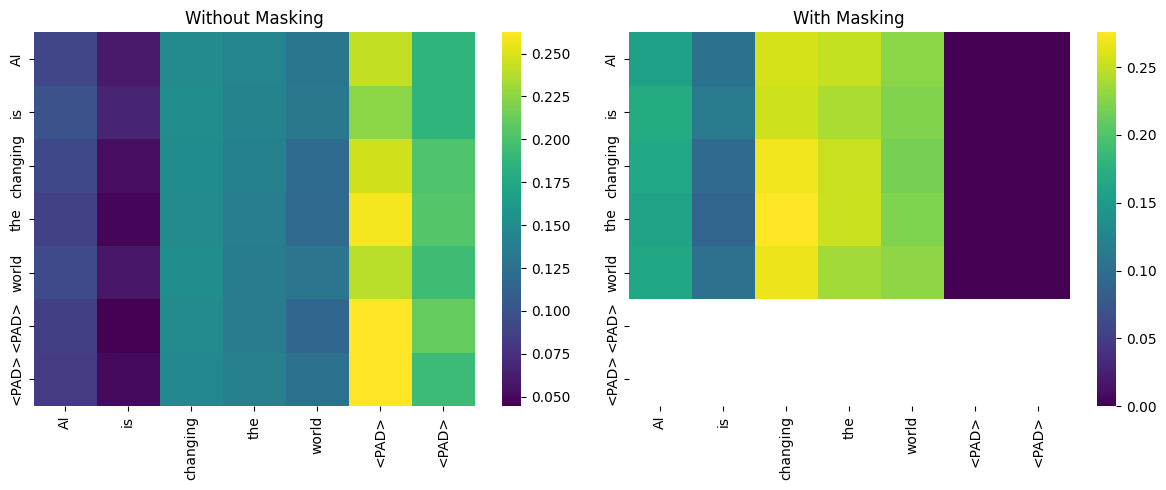

In [31]:
sentence_masked = ["AI", "is", "changing", "the", "world", "<PAD>", "<PAD>"]
n = len(sentence_masked)
inputs = np.random.rand(n, d_model)

mask = np.array([1,1,1,1,1,0,0])
mask_matrix = np.outer(mask, mask)

Q = np.dot(inputs, Wq)
K = np.dot(inputs, Wk)
V = np.dot(inputs, Wv)
scores = np.dot(Q, K.T) / np.sqrt(d_model)

scores_masked = np.where(mask_matrix == 1, scores, -1e9)
weights_nomask = softmax(scores)
weights_masked = softmax(scores_masked)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(weights_nomask, cmap='viridis', xticklabels=sentence_masked, yticklabels=sentence_masked)
plt.title("Without Masking")
plt.subplot(1,2,2)
sns.heatmap(weights_masked, cmap='viridis', xticklabels=sentence_masked, yticklabels=sentence_masked)
plt.title("With Masking")
plt.tight_layout()
plt.show()


Exo 6 : 

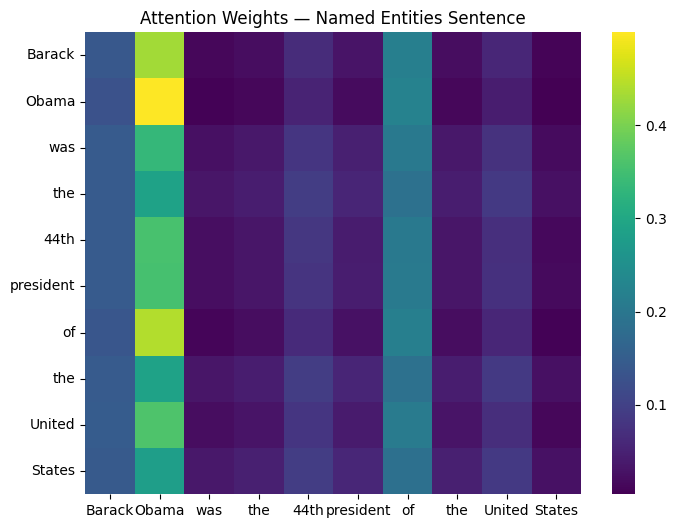

In [32]:
def softmax(x):
    return np.exp(x) / np.sum(np.exp(x), axis=-1, keepdims=True)

sentence = ["Barack", "Obama", "was", "the", "44th", "president", "of", "the", "United", "States"]

np.random.seed(0)
embeddings = {word: np.random.rand(6) for word in sentence}
inputs = np.array([embeddings[w] for w in sentence])
d_model = inputs.shape[1]

Wq = np.random.rand(d_model, d_model)
Wk = np.random.rand(d_model, d_model)
Wv = np.random.rand(d_model, d_model)

Q = np.dot(inputs, Wq)
K = np.dot(inputs, Wk)
V = np.dot(inputs, Wv)

scores = np.dot(Q, K.T) / np.sqrt(d_model)
weights = softmax(scores)
output = np.dot(weights, V)

plt.figure(figsize=(8,6))
sns.heatmap(weights, cmap='viridis', xticklabels=sentence, yticklabels=sentence)
plt.title('Attention Weights — Named Entities Sentence')
plt.show()


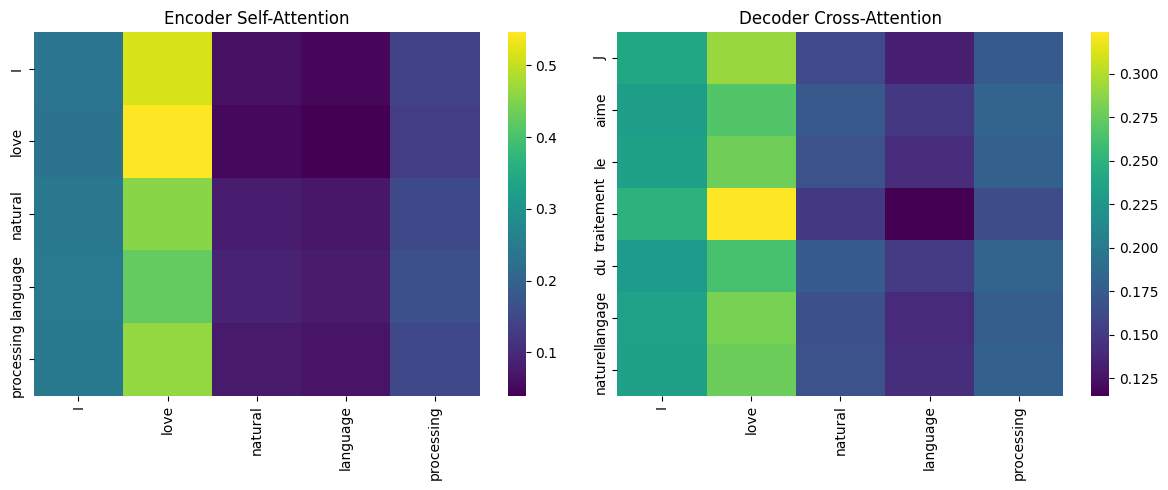

In [34]:
encoder_sentence = ["I", "love", "natural", "language", "processing"]
decoder_sentence = ["J", "aime", "le", "traitement", "du", "langage", "naturel"]

np.random.seed(42)
enc_inputs = np.random.rand(len(encoder_sentence), 6)
dec_inputs = np.random.rand(len(decoder_sentence), 6)

Wq_enc = np.random.rand(6,6)
Wk_enc = np.random.rand(6,6)
Wv_enc = np.random.rand(6,6)

Wq_dec = np.random.rand(6,6)
Wk_dec = np.random.rand(6,6)
Wv_dec = np.random.rand(6,6)

Qe = np.dot(enc_inputs, Wq_enc)
Ke = np.dot(enc_inputs, Wk_enc)
Ve = np.dot(enc_inputs, Wv_enc)
weights_enc = softmax(np.dot(Qe, Ke.T) / np.sqrt(6))
encoder_output = np.dot(weights_enc, Ve)

Qd = np.dot(dec_inputs, Wq_dec)
Kd = np.dot(encoder_output, Wk_enc)
Vd = np.dot(encoder_output, Wv_enc)
weights_cross = softmax(np.dot(Qd, Kd.T) / np.sqrt(6))
decoder_output = np.dot(weights_cross, Vd)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(weights_enc, cmap='viridis', xticklabels=encoder_sentence, yticklabels=encoder_sentence)
plt.title("Encoder Self-Attention")
plt.subplot(1,2,2)
sns.heatmap(weights_cross, cmap='viridis', xticklabels=encoder_sentence, yticklabels=decoder_sentence)
plt.title("Decoder Cross-Attention")
plt.tight_layout()
plt.show()


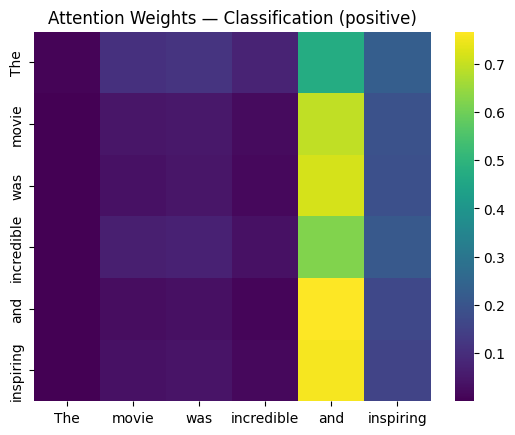

Predicted sentiment: positive


In [35]:
sentence = ["The", "movie", "was", "incredible", "and", "inspiring"]
labels = ["negative", "positive"]

np.random.seed(1)
inputs = np.random.rand(len(sentence), 8)
d_model = 8

Wq = np.random.rand(8,8)
Wk = np.random.rand(8,8)
Wv = np.random.rand(8,8)
Q = np.dot(inputs, Wq)
K = np.dot(inputs, Wk)
V = np.dot(inputs, Wv)

scores = np.dot(Q, K.T) / np.sqrt(8)
weights = softmax(scores)
attention_output = np.dot(weights, V)

sentence_vector = np.mean(attention_output, axis=0)
W_class = np.random.rand(8, 2)
logits = np.dot(sentence_vector, W_class)
pred = labels[np.argmax(logits)]

sns.heatmap(weights, cmap='viridis', xticklabels=sentence, yticklabels=sentence)
plt.title(f'Attention Weights — Classification ({pred})')
plt.show()

print("Predicted sentiment:", pred)


Exo 7 

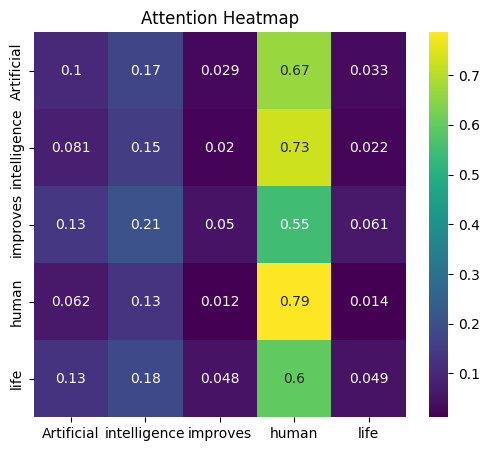

In [36]:
def softmax(x):
    return np.exp(x) / np.sum(np.exp(x), axis=-1, keepdims=True)

sentence = ["Artificial", "intelligence", "improves", "human", "life"]

np.random.seed(0)
inputs = np.random.rand(len(sentence), 6)
d_model = inputs.shape[-1]

Wq = np.random.rand(d_model, d_model)
Wk = np.random.rand(d_model, d_model)
Wv = np.random.rand(d_model, d_model)
Q = np.dot(inputs, Wq)
K = np.dot(inputs, Wk)
V = np.dot(inputs, Wv)

scores = np.dot(Q, K.T) / np.sqrt(d_model)
weights = softmax(scores)
def plot_attention_heatmap(weights, sentence):
    plt.figure(figsize=(6,5))
    sns.heatmap(weights, annot=True, cmap="viridis",
                xticklabels=sentence, yticklabels=sentence)
    plt.title("Attention Heatmap")
    plt.show()

plot_attention_heatmap(weights, sentence)


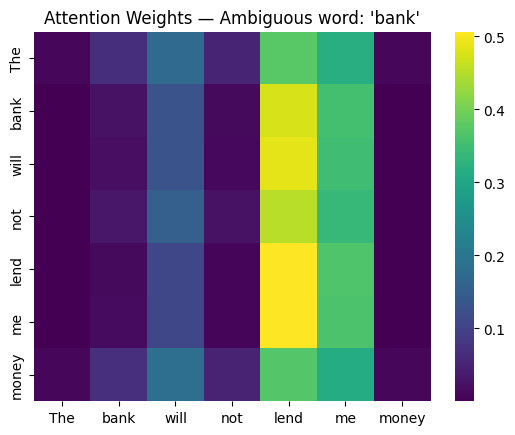

In [37]:

sentence = ["The", "bank", "will", "not", "lend", "me", "money"]

np.random.seed(1)
inputs = np.random.rand(len(sentence), 8)
d_model = 8

Wq = np.random.rand(8,8)
Wk = np.random.rand(8,8)
Wv = np.random.rand(8,8)
Q = np.dot(inputs, Wq)
K = np.dot(inputs, Wk)
V = np.dot(inputs, Wv)

scores = np.dot(Q, K.T) / np.sqrt(8)
weights = softmax(scores)

sns.heatmap(weights, cmap="viridis", xticklabels=sentence, yticklabels=sentence)
plt.title("Attention Weights — Ambiguous word: 'bank'")
plt.show()


In [38]:
from ipywidgets import interact, Text

def interactive_attention(sentence_text):
    words = sentence_text.split()
    np.random.seed(0)
    inputs = np.random.rand(len(words), 6)
    d_model = 6
    Wq = np.random.rand(d_model, d_model)
    Wk = np.random.rand(d_model, d_model)
    Wv = np.random.rand(d_model, d_model)
    Q = np.dot(inputs, Wq)
    K = np.dot(inputs, Wk)
    V = np.dot(inputs, Wv)
    scores = np.dot(Q, K.T) / np.sqrt(d_model)
    weights = softmax(scores)
    plt.figure(figsize=(6,5))
    sns.heatmap(weights, cmap="viridis", xticklabels=words, yticklabels=words)
    plt.title("Interactive Attention Map")
    plt.show()

interact(interactive_attention,
         sentence_text=Text(value="I love natural language processing",
                            description="Sentence:"))


interactive(children=(Text(value='I love natural language processing', description='Sentence:'), Output()), _d…

<function __main__.interactive_attention(sentence_text)>

Exo 8 

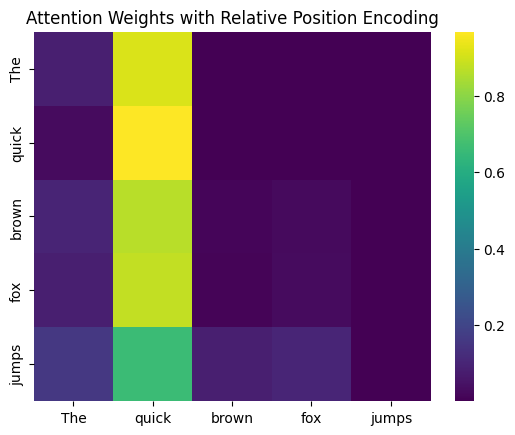

In [42]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def softmax(x):
    return np.exp(x) / np.sum(np.exp(x), axis=-1, keepdims=True)

sentence=["The","quick","brown","fox","jumps"]
n=len(sentence);d_model=6
np.random.seed(0)
inputs=np.random.rand(n,d_model)

def positional_encoding(position,d_model):
    PE=np.zeros((position,d_model))
    for pos in range(position):
        for i in range(0,d_model,2):
            PE[pos,i]=np.sin(pos/(10000**((2*i)/d_model)))
            if i+1<d_model:PE[pos,i+1]=np.cos(pos/(10000**((2*i)/d_model)))
    return PE

def relative_position_encoding(n,d_model):
    rel=np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            rel[i,j]=abs(i-j)
    rel=np.exp(-rel/2)
    return rel

pos_enc=positional_encoding(n,d_model)
inputs_pos=inputs+pos_enc
Wq=np.random.rand(d_model,d_model)
Wk=np.random.rand(d_model,d_model)
Wv=np.random.rand(d_model,d_model)
Q=np.dot(inputs_pos,Wq)
K=np.dot(inputs_pos,Wk)
V=np.dot(inputs_pos,Wv)
rel_bias=relative_position_encoding(n,d_model)
scores=np.dot(Q,K.T)/np.sqrt(d_model)+rel_bias
weights=softmax(scores)

sns.heatmap(weights,cmap="viridis",xticklabels=sentence,yticklabels=sentence)
plt.title("Attention Weights with Relative Position Encoding")
plt.show()


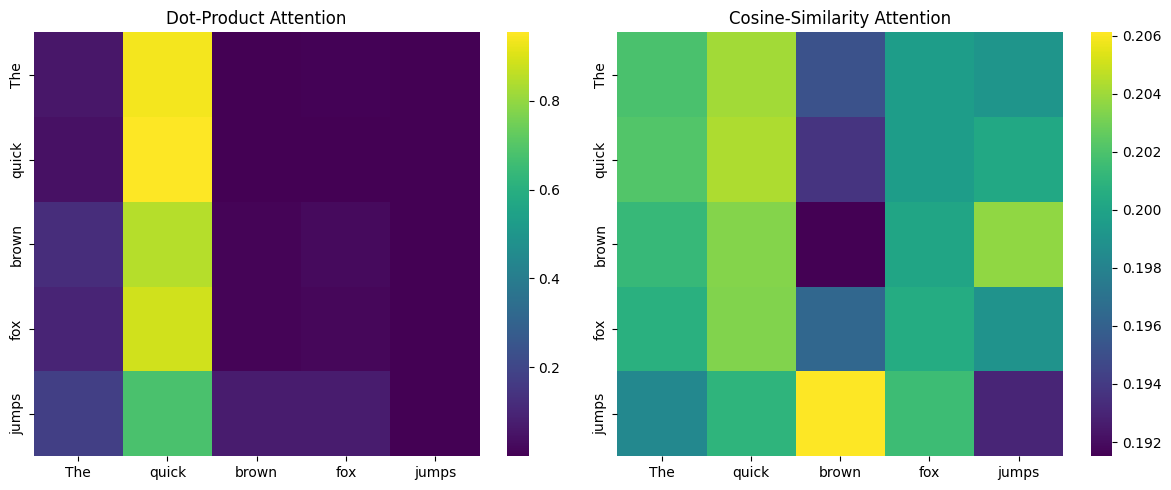

In [43]:
from numpy.linalg import norm

def softmax(x):
    return np.exp(x) / np.sum(np.exp(x), axis=-1, keepdims=True)

def cosine_similarity_attention(Q,K,V):
    cosine_sim=np.dot(Q,K.T)/(norm(Q,axis=1,keepdims=True)*norm(K,axis=1))
    weights=softmax(cosine_sim)
    output=np.dot(weights,V)
    return weights,output

scores_dot=np.dot(Q,K.T)/np.sqrt(d_model)
weights_dot=softmax(scores_dot)
weights_cos,output_cos=cosine_similarity_attention(Q,K,V)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(weights_dot,cmap="viridis",xticklabels=sentence,yticklabels=sentence)
plt.title("Dot-Product Attention")
plt.subplot(1,2,2)
sns.heatmap(weights_cos,cmap="viridis",xticklabels=sentence,yticklabels=sentence)
plt.title("Cosine-Similarity Attention")
plt.tight_layout()
plt.show()

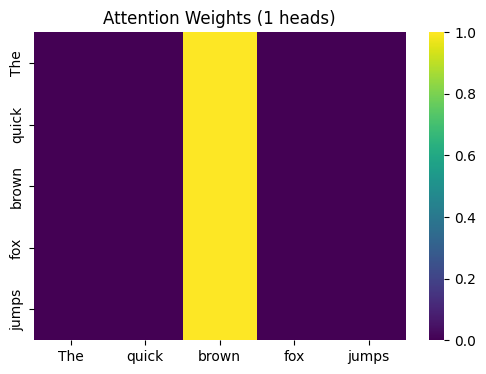

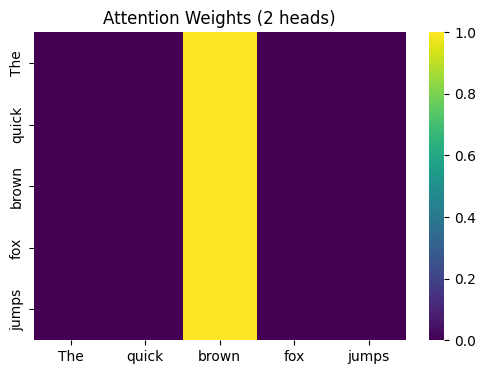

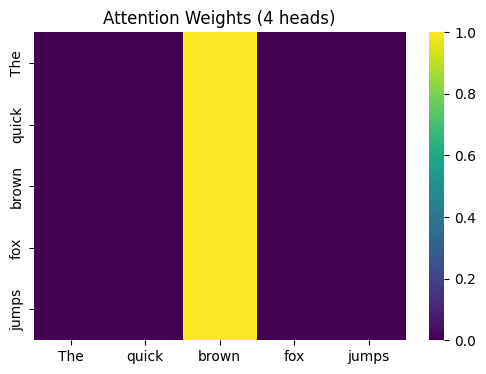

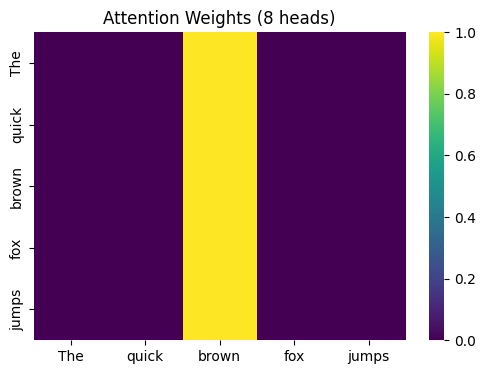

In [45]:
def softmax(x):
    return np.exp(x)/np.sum(np.exp(x),axis=-1,keepdims=True)

sentence=["The","quick","brown","fox","jumps"]
d_model=8
np.random.seed(0)
inputs=np.random.rand(len(sentence),d_model)

Wq=np.random.rand(d_model,d_model)
Wk=np.random.rand(d_model,d_model)
Wv=np.random.rand(d_model,d_model)
Q=np.dot(inputs,Wq)
K=np.dot(inputs,Wk)
V=np.dot(inputs,Wv)

def multi_head_attention(Q,K,V,num_heads):
    d_model=Q.shape[-1]
    assert d_model%num_heads==0
    outputs=[]
    for _ in range(num_heads):
        Wq=np.random.rand(d_model,d_model)
        Wk=np.random.rand(d_model,d_model)
        Wv=np.random.rand(d_model,d_model)
        Qh=np.dot(Q,Wq)
        Kh=np.dot(K,Wk)
        Vh=np.dot(V,Wv)
        scores=np.dot(Qh,Kh.T)/np.sqrt(d_model)
        weights=softmax(scores)
        outputs.append(np.dot(weights,Vh))
    return np.mean(outputs,axis=0),weights

heads_list=[1,2,4,8]
for h in heads_list:
    output_h,weights_h=multi_head_attention(Q,K,V,h)
    plt.figure(figsize=(6,4))
    sns.heatmap(weights_h,cmap='viridis',xticklabels=sentence,yticklabels=sentence)
    plt.title(f'Attention Weights ({h} heads)')
    plt.show()


Exo 9 

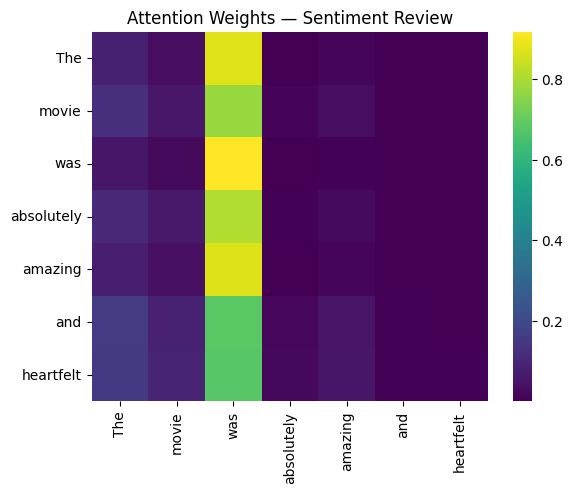

In [46]:
import numpy as np, seaborn as sns, matplotlib.pyplot as plt
def softmax(x): return np.exp(x)/np.sum(np.exp(x),axis=-1,keepdims=True)

sentence=["The","movie","was","absolutely","amazing","and","heartfelt"]
np.random.seed(0); d_model=8
inputs=np.random.rand(len(sentence),d_model)
Wq=np.random.rand(d_model,d_model);Wk=np.random.rand(d_model,d_model);Wv=np.random.rand(d_model,d_model)
Q=np.dot(inputs,Wq);K=np.dot(inputs,Wk);V=np.dot(inputs,Wv)
scores=np.dot(Q,K.T)/np.sqrt(d_model);weights=softmax(scores);output=np.dot(weights,V)
sns.heatmap(weights,cmap="viridis",xticklabels=sentence,yticklabels=sentence)
plt.title("Attention Weights — Sentiment Review");plt.show()


- AI systems assist in medical diagnosis.
- Deep learning enables image and speech recognition.


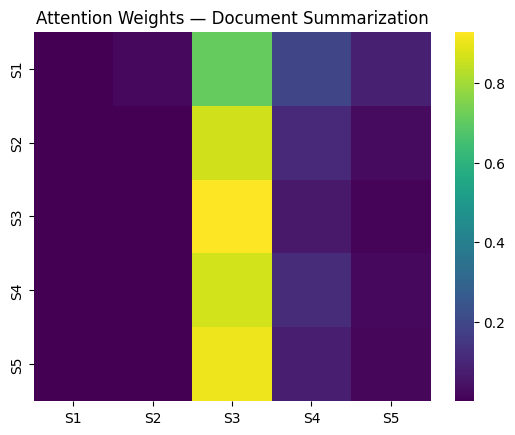

In [47]:
text=["Artificial intelligence is transforming industries.",
      "Machine learning models learn from data.",
      "Deep learning enables image and speech recognition.",
      "AI systems assist in medical diagnosis.",
      "These technologies shape the future."]
np.random.seed(1); d_model=10
inputs=np.random.rand(len(text),d_model)
Wq=np.random.rand(d_model,d_model);Wk=np.random.rand(d_model,d_model);Wv=np.random.rand(d_model,d_model)
Q=np.dot(inputs,Wq);K=np.dot(inputs,Wk);V=np.dot(inputs,Wv)
scores=np.dot(Q,K.T)/np.sqrt(d_model);weights=np.exp(scores)/np.sum(np.exp(scores),axis=-1,keepdims=True)
importance=np.mean(weights,axis=0);summary_idx=np.argsort(importance)[-2:]
for i in summary_idx: print("-",text[i])
sns.heatmap(weights,cmap="viridis",xticklabels=[f"S{i+1}" for i in range(len(text))],
            yticklabels=[f"S{i+1}" for i in range(len(text))])
plt.title("Attention Weights — Document Summarization");plt.show()


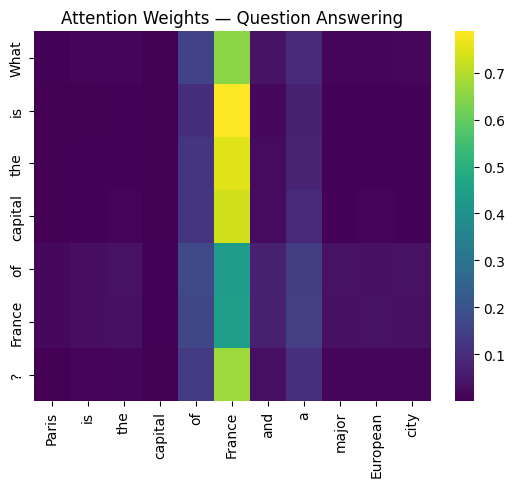

In [48]:
context=["Paris","is","the","capital","of","France","and","a","major","European","city"]
question=["What","is","the","capital","of","France","?"]
np.random.seed(2); d_model=8
C=np.random.rand(len(context),d_model);Qn=np.random.rand(len(question),d_model)
Wq=np.random.rand(d_model,d_model);Wk=np.random.rand(d_model,d_model);Wv=np.random.rand(d_model,d_model)
Qv=np.dot(Qn,Wq);Kc=np.dot(C,Wk);Vc=np.dot(C,Wv)
scores=np.dot(Qv,Kc.T)/np.sqrt(d_model);weights=np.exp(scores)/np.sum(np.exp(scores),axis=-1,keepdims=True)
sns.heatmap(weights,cmap="viridis",xticklabels=context,yticklabels=question)
plt.title("Attention Weights — Question Answering");plt.show()
